In [61]:
from metasyn import demo_data, MetaFrame
import numpy as np
import polars as pl
from matplotlib import pyplot as plt
from metasyn.distribution import ContinuousNormalDistribution, ContinuousUniformDistribution, ContinuousConstantDistribution

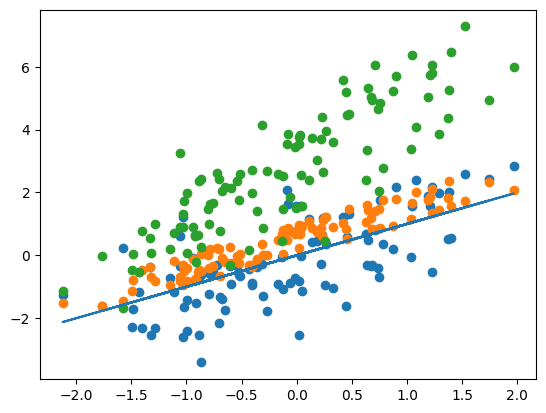

In [58]:
base = np.random.randn(100)
corr = np.random.randn(100) + base
constrained = np.random.rand(100) + base
linear = 3+2*base + np.random.randn(100)
df = pl.DataFrame({"base": base, "correlated": corr, "larger": constrained, "linear": linear})
plt.scatter(df["base"], df["correlated"])
plt.scatter(df["base"], df["larger"])
plt.plot(df["base"], df["base"])
plt.scatter(df["base"], df["linear"])
plt.show()


      larger: 100%|██████████| 3/3 [00:00<00:00, 1070.61variables/s]


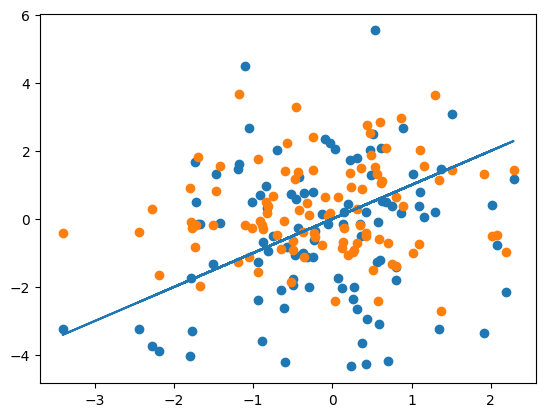

In [22]:
mf = MetaFrame.fit_dataframe(df)
df_syn = mf.synthesize(100)
plt.scatter(df_syn["base"], df_syn["correlated"])
plt.scatter(df_syn["base"], df_syn["larger"])
plt.plot(df_syn["base"], df_syn["base"])
plt.show()

In [79]:
form_correlated = [{"type": "column", "name": "base"}, {"type": "operator", "operator": "+"}, {"type": "distribution", "distribution": ContinuousNormalDistribution(0, 1)}]
form_constrained = [{"type": "column", "name": "base"},  {"type": "operator", "operator": "+"}, {"type": "distribution", "distribution": ContinuousUniformDistribution(0, 1)}]
form_linear = [{"type": "distribution", "distribution": ContinuousConstantDistribution(3.0)}, {"type": "operator", "operator": "+"}, [{"type": "distribution", "distribution": ContinuousConstantDistribution(2.0)}, {"type": "operator", "operator": "*"}, {"type": "column", "name": "base"}], {"type": "operator", "operator": "+"}, {"type": "distribution", "distribution": ContinuousNormalDistribution(0, 1)}]

In [ ]:
def parse_constraint(df_syn, form):
    current_result = None
    last_operator = None
    for item in form:
        if isinstance(item, list):
            data = parse_constraint(df_syn, item)
        elif item["type"] == "column":
            data = df_syn[item["name"]]
        elif item["type"] == "distribution":
            dist = item["distribution"]
            try:
                data = pl.Series(dist.draw_list(len(df_syn)))
            except NotImplementedError:
                data = pl.Series([dist.draw() for _ in range(len(df_syn))])
        elif item["type"] == "operator":
            last_operator = item["operator"]
            continue
        if current_result is None:
            current_result = data
        else:
            match last_operator:
                case "+":
                    current_result = current_result + data
                case "*":
                    current_result = current_result * data
                case _:
                    raise ValueError()
    return current_result

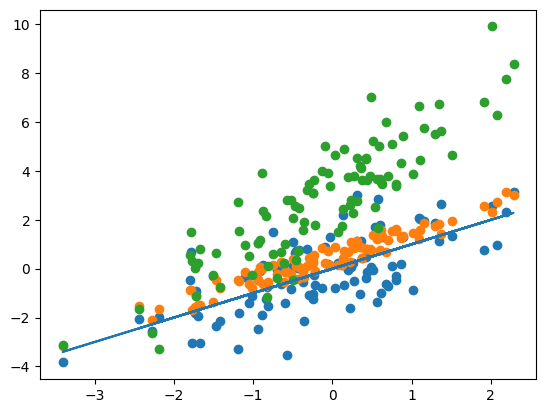

In [82]:
plt.scatter(df_syn["base"], parse_constraint(df_syn, form_correlated))
plt.scatter(df_syn["base"], parse_constraint(df_syn, form_constrained))
plt.scatter(df_syn["base"], parse_constraint(df_syn, form_linear))
plt.plot(df_syn["base"], df_syn["base"])
plt.show()